# Нейросеть для предсказания калорийности блюд
## Русаков Егор

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

## Исследовательский анализ (EDA)

In [2]:
dishes = pd.read_csv('data/dish.csv')
ingredients = pd.read_csv('data/ingredients.csv')

display(dishes.head())
display(ingredients.head())

dishes.info()
ingredients.info()

print(f"Блюд: {len(dishes)}, Ингредиентов: {len(ingredients)}")

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB
Блюд: 3262, Ингредиентов: 555


In [3]:
id_to_name = dict(zip(
    ingredients["id"].map(lambda ingredient_id: f"ingr_{ingredient_id:010d}"),
    ingredients["ingr"],
))

dishes["ingredients"] = dishes["ingredients"].map(
    lambda ids: ", ".join(id_to_name[token] for token in ids.split(";"))
)

dishes.head()

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,"soy sauce, garlic, white rice, parsley, onions...",test
1,dish_1561662054,419.438782,292.0,"pepper, white rice, mixed greens, garlic, soy ...",train
2,dish_1562008979,382.936646,290.0,"jalapenos, lemon juice, pork, wheat berry, cab...",test
3,dish_1560455030,20.590000,103.0,"cherry tomatoes, cucumbers, baby carrots",train
4,dish_1558372433,74.360001,143.0,deprecated,train


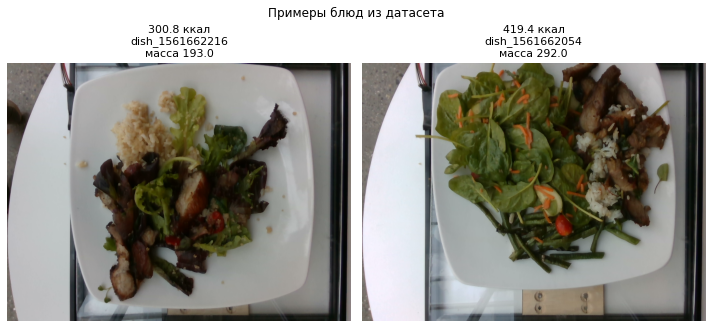

In [4]:
def show_dishes(frame, title):
    n = len(frame)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, frame.iterrows()):
        image = Image.open(os.path.join("data/images", row["dish_id"], "rgb.png"))
        ax.imshow(image)
        ax.set_title(
            f"{row['total_calories']:.1f} ккал\n{row['dish_id']}\nмасса {row['total_mass']:.1f}",
            fontsize=11,
        )
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_dishes(dishes.head(2), "Примеры блюд из датасета")

Медиана: 209.110062, Среднее: 255.0127380726548


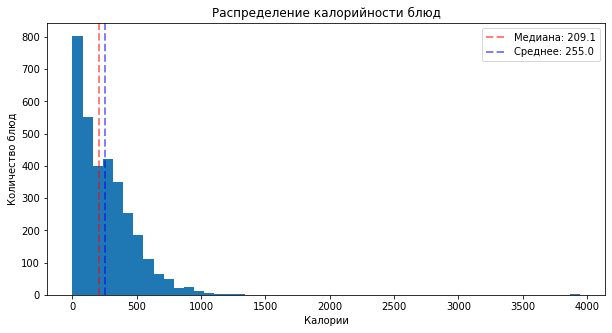

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(dishes['total_calories'], bins=50)

median = dishes['total_calories'].median()
avg = dishes['total_calories'].mean()

print(f"Медиана: {median}, Среднее: {avg}")

plt.axvline(median, color='red', linestyle='--', linewidth=2, alpha=0.5, label=f'Медиана: {median:.1f}')
plt.axvline(avg, color='blue', linestyle='--', linewidth=2, alpha=0.5, label=f'Среднее: {avg:.1f}')

plt.title("Распределение калорийности блюд")
plt.xlabel("Калории")
plt.ylabel("Количество блюд")
plt.legend() 
plt.show()


В среднем коллорийность блюд составляет 255 кКал. Выбросов практически нет, что говорит о хорошем качестве предоставленных данных. Редкие исключения - блюда с калорийностью 1000 кКал и более. Рассмотрим выбросы детальнее.


Количество блюд с калорийностью более 1000 кКал: 19


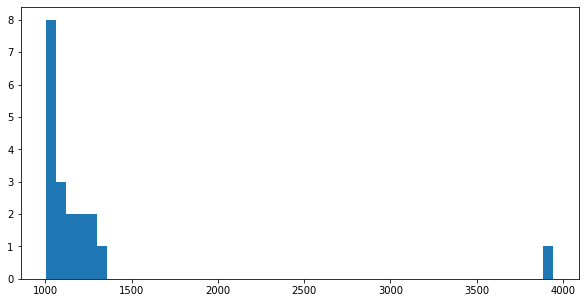

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(dishes['total_calories'][dishes['total_calories'] > 1000], bins=50);
print(f'Количество блюд с калорийностью более 1000 кКал: {len(dishes[dishes["total_calories"] > 1000])}')


Из всего датасета явным выбросам подвержено лишь 19 записей о блюдах. Оставим их как есть.

,dish_id,total_calories,total_mass,ingredients
263,dish_1557861216,0.00,1.0,plate only
2652,dish_1556575700,0.00,86.0,plate only
195,dish_1558461431,1.15,5.0,spinach (raw)


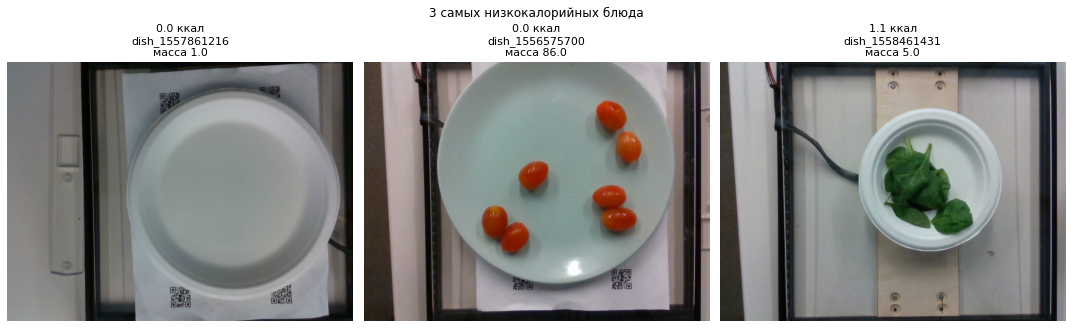

,dish_id,total_calories,total_mass,ingredients
1518,dish_1560974769,3943.325195,3051.0,"spinach (raw), tortilla chips, corn, cheese, w..."
124,dish_1565033265,1324.084961,625.0,"olives, mixed greens, broccoli, chicken, vinai..."
2753,dish_1562603895,1268.157349,517.0,"blackberries, mixed greens, vinaigrette, hash ..."


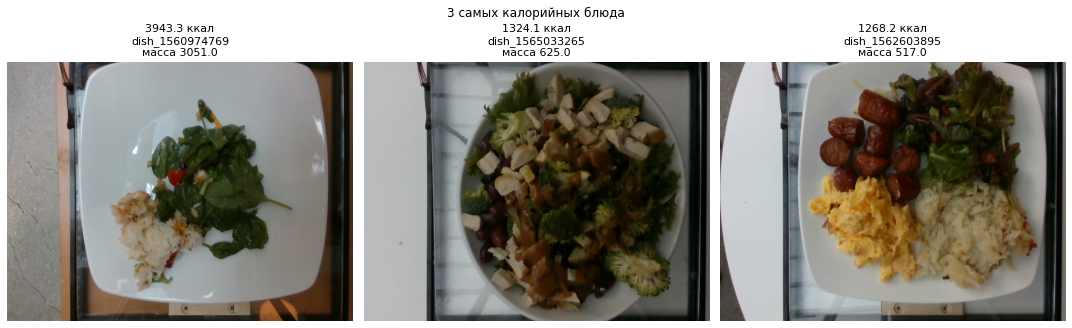

In [6]:
lowest = dishes.nsmallest(3, "total_calories")
highest = dishes.nlargest(3, "total_calories")

display(lowest[["dish_id", "total_calories", "total_mass", "ingredients"]])
show_dishes(lowest, "3 самых низкокалорийных блюда")

display(highest[["dish_id", "total_calories", "total_mass", "ingredients"]])
show_dishes(highest, "3 самых калорийных блюда")

На фотографии слева замечается явный выброс, масса блюда точно не соотвествует заявленным 3000 граммам.

Медиана: 4.0, Среднее: 7.313304721030043


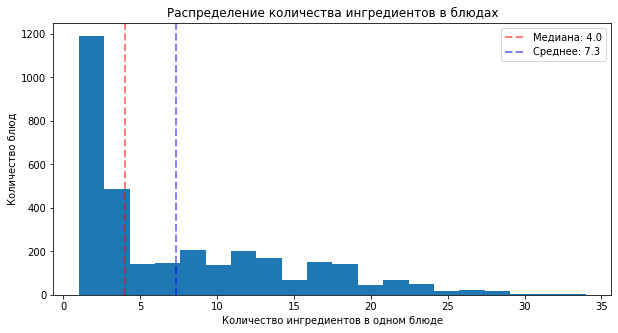

In [7]:
ingredients_count = dishes['ingredients'].str.split(',').str.len()

median = ingredients_count.median()
avg = ingredients_count.mean()

print(f"Медиана: {median}, Среднее: {avg}")

plt.figure(figsize=(10, 5))
plt.hist(ingredients_count, bins=20)

plt.axvline(median, color='red', linestyle='--', linewidth=2, alpha=0.5, label=f'Медиана: {median:.1f}')
plt.axvline(avg, color='blue', linestyle='--', linewidth=2, alpha=0.5, label=f'Среднее: {avg:.1f}')

plt.title("Распределение количества ингредиентов в блюдах")
plt.xlabel("Количество ингредиентов в одном блюде")
plt.ylabel("Количество блюд")
plt.legend()
plt.show()


В среднем в каждом блюде содержится 7 ингредиентов. 

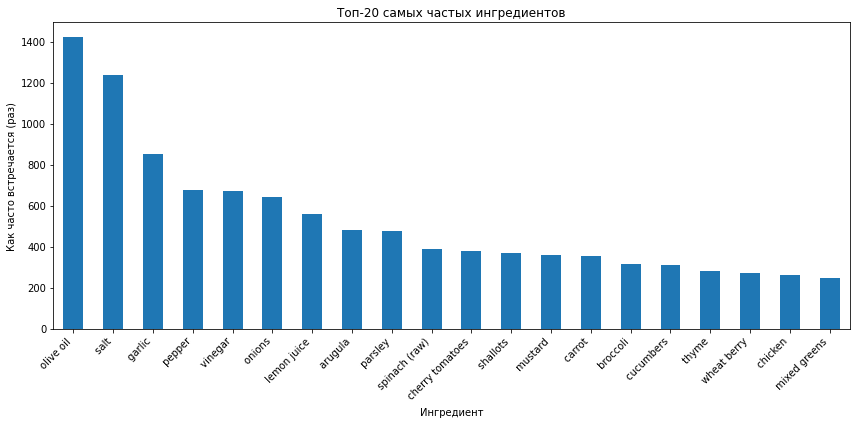

ingredients
 olive oil          1423
 salt               1236
 garlic              852
 pepper              676
 vinegar             669
 onions              642
 lemon juice         557
 arugula             483
 parsley             477
 spinach (raw)       386
 cherry tomatoes     380
 shallots            367
 mustard             358
 carrot              355
 broccoli            316
 cucumbers           308
 thyme               282
 wheat berry         273
 chicken             262
 mixed greens        249
Name: count, dtype: int64

In [8]:
top_ingredients = dishes['ingredients'].str.split(',').explode().value_counts().head(20)

plt.figure(figsize=(12, 6))
top_ingredients.plot(kind='bar')

plt.title("Топ-20 самых частых ингредиентов")
plt.xlabel("Ингредиент")
plt.ylabel("Как часто встречается (раз)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

top_ingredients.head(20)


Выведен топ-20 самых частых ингредиентов, которые встречаются в блюдах.